# Introduction to ROOT package
Author: Marcin Konecki
# Example 0
type root in shell and try some simple calculations, draw simple TF1 function and browse a root file

# Before Example 1 - prepare data points with numpy

In [44]:
#! /usr/bin/env python
# -*- coding: utf-8 -*-

import sys
import numpy as np

np.random.seed(2024)
throws = np.random.randint(1,6+1,size=(130,2))
np.savetxt('data_dice.txt',throws, fmt='%1d')
print("throws:\n",throws)

throws:
 [[1 3]
 [1 1]
 [4 5]
 [2 2]
 [5 4]
 [3 3]
 [1 6]
 [5 2]
 [3 4]
 [5 4]
 [3 2]
 [3 5]
 [3 2]
 [4 6]
 [6 6]
 [4 5]
 [2 5]
 [1 3]
 [2 3]
 [3 1]
 [1 6]
 [6 1]
 [1 4]
 [6 4]
 [4 1]
 [1 6]
 [6 1]
 [1 5]
 [6 4]
 [2 1]
 [2 2]
 [6 6]
 [1 5]
 [6 3]
 [4 3]
 [4 5]
 [3 4]
 [6 3]
 [5 2]
 [1 2]
 [6 5]
 [4 3]
 [4 4]
 [1 3]
 [4 5]
 [3 6]
 [1 4]
 [2 2]
 [5 1]
 [4 4]
 [2 5]
 [5 3]
 [3 1]
 [4 6]
 [5 5]
 [6 1]
 [1 4]
 [3 3]
 [2 4]
 [4 3]
 [6 1]
 [1 4]
 [6 4]
 [5 4]
 [5 1]
 [6 5]
 [5 5]
 [3 4]
 [3 5]
 [2 2]
 [3 5]
 [2 2]
 [6 5]
 [4 6]
 [1 1]
 [3 6]
 [3 4]
 [3 3]
 [1 1]
 [6 1]
 [3 3]
 [2 1]
 [2 4]
 [3 2]
 [1 4]
 [6 4]
 [4 1]
 [2 4]
 [3 4]
 [2 4]
 [6 5]
 [4 2]
 [1 2]
 [2 6]
 [5 5]
 [5 2]
 [3 3]
 [3 3]
 [1 2]
 [5 5]
 [6 2]
 [4 4]
 [5 2]
 [1 6]
 [1 6]
 [5 4]
 [2 5]
 [3 6]
 [5 4]
 [2 4]
 [6 2]
 [5 4]
 [3 1]
 [6 3]
 [3 6]
 [6 3]
 [3 2]
 [6 2]
 [3 4]
 [1 6]
 [6 5]
 [1 2]
 [4 1]
 [4 3]
 [1 6]
 [2 1]
 [2 6]
 [4 5]
 [6 3]
 [6 4]]


# Example 1 - histogramming

number of    throws1: 130, number of throws2: 130
number of all throws: 260, number of combined throws: 130


Info in <TCanvas::Print>: png file ./cDice.png has been created


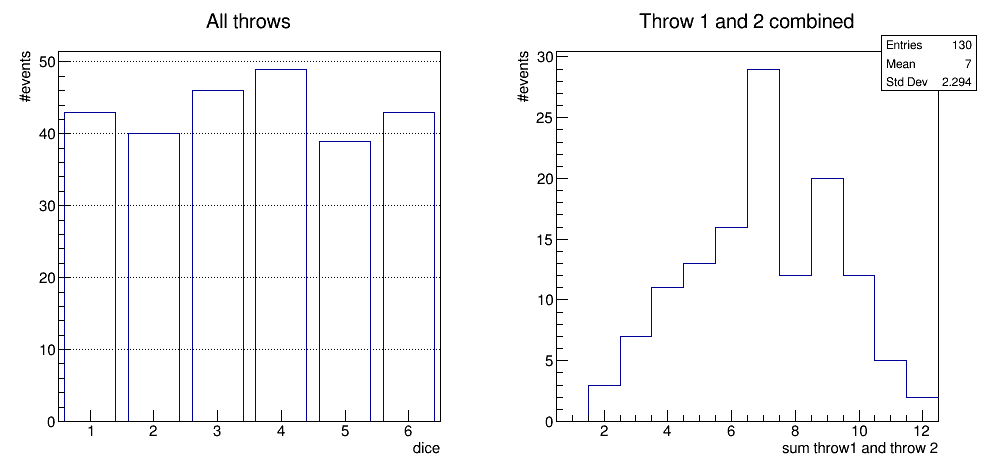

In [ ]:
#! /usr/bin/env python
# -*- coding: utf-8 -*-

import sys
from ROOT import TCanvas,TH1D,TFile
import numpy as np

#
#
#
def readData(fileName, throw1, throw2) :
  file = open(fileName,'r')
  for line in file:
    columns = line.strip().split()
    throw1.append(int(columns[0]))
    throw2.append(int(columns[1]))
  return

#
# read data from a text file
#
throw1 = []
throw2 = []
readData('data_dice.txt', throw1, throw2)

#
# print data 
#
allDice=throw1+throw2
sumDice=np.add(throw1,throw2)
print ('number of    throws1: {0:2d}, number of throws2: {1:2d}'.format(len(throw1),len(throw2)) )
print ('number of all throws: {0:2d}, number of combined throws: {1:2d}'.format(len(allDice),len(sumDice)) )

#
# define a Canva and histogram
#
c = TCanvas('cDice','cDice',1000,500)
c.Divide(2,1)
hDice = TH1D('hDice','All throws; dice; #events',6,0.5,6.5)
hDice.Sumw2() #redundant action, as its conducted automatically 
hDiceSum = TH1D('hDiceSum','Throw 1 and 2 combined; sum of dice; #events',12,0.5,12.5)
hDiceSum.Sumw2()

# decorations 
hDice.SetMinimum(0) 
hDice.GetXaxis().SetNdivisions(106)
hDice.SetStats(0)
hDice.SetFillStyle(1)
#hDice.SetFillStyle(3444)
#hDice.SetFillColor(kGreen)
#hDice.SetLineWidth(2)
#hDice.SetLineColor(kRed)
hDice.SetLineStyle(3)
hDice.SetBarWidth(0.8)
hDice.SetBarOffset(0.1)
c.SetGrid(0,1)

for i in range(len(allDice)) :
  hDice.Fill( allDice[i])
for i in range(len(sumDice)) :
  hDiceSum.Fill( sumDice[i])

pad1=c.cd(1)
pad1.SetGrid(0,1)
hDice.DrawCopy('b histo')

#

c.cd(2)
hDiceSum.SetMinimum(0.)
hDiceSum.GetXaxis().SetTitle("sum throw1 and throw 2")
#fill bin x=1 with weight 4.
#hDiceSum.Fill(1,4)
#for test of Sumw2() play below
#it seems that in current version of ROOT Sumw2() is switched on 
#irrespectively of settings, when filling with weight is done.
#to switch it off (do not do that!) uncomment libe below after filling, before plotting
#hDiceSum.Sumw2(kFALSE)

hDiceSum.DrawCopy('histo')
#hDiceSum.DrawCopy('E same')



c.Draw()
c.Print('.png')


#input('press enter to store histo and exit')
outfile=TFile.Open('histos.root',"RECREATE")
outfile.cd()
hDice.Write()
hDiceSum.Write()
outfile.Close()

#cleanup
hDice.Delete()
hDiceSum.Delete()
#c.Close()


# Example 2 
access to histograms, graphs, decorations

sum of entries:  260.0
integral:        260.0
integral:        1.0
bin 1 [ 0.50, 1.50[ = 0.165
bin 2 [ 1.50, 2.50[ = 0.154
bin 3 [ 2.50, 3.50[ = 0.177
bin 4 [ 3.50, 4.50[ = 0.188
bin 5 [ 4.50, 5.50[ = 0.150
bin 6 [ 5.50, 6.50[ = 0.165
TFile**		histos.root	
 TFile*		histos.root	
  KEY: TH1D	hDice;1	All throws
  KEY: TH1D	hDiceSum;1	Throw 1 and 2 combined


Info in <TCanvas::Print>: png file cDrawings.png has been created


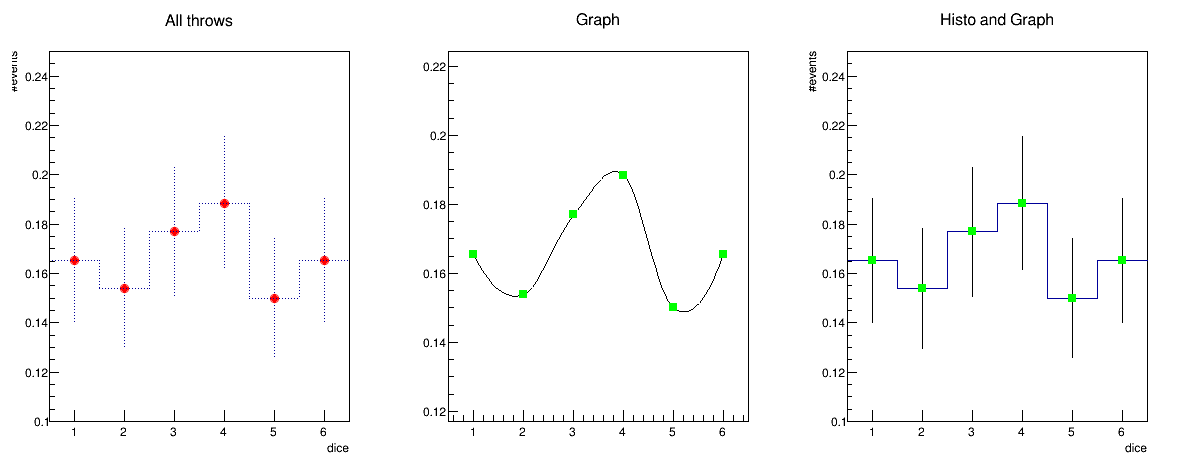

In [3]:
#!/usr/bin/python3
#from ROOT import *
from ROOT import TCanvas,TH1D,TFile,TGraphErrors
f=TFile('histos.root')
f.ls()
hDice=f.Get('hDice')
#hDice.Print("all")

print("sum of entries: ",hDice.GetEntries())
print("integral:       ",hDice.Integral() )
hDice.Scale(1./hDice.Integral())
hDice.SetMarkerStyle(20)
hDice.SetMarkerColor(2)
hDice.SetMinimum(0.1)
hDice.SetMaximum(0.25)
hDice.SetLineStyle(3)
print("integral:       ",hDice.Integral() )
nbins=hDice.GetNbinsX()

#acess to content bin-by-bin.
# bin==1 underflow
# bin=nbins+1 overflow
for i in range(1,nbins+1):
    print("bin %d [%5.2f,%5.2f[ = %4.3f"% (i,hDice.GetBinLowEdge(i),hDice.GetBinLowEdge(i+1),hDice.GetBinContent(i)))
    
gr=TGraphErrors(nbins)
gr.SetMarkerStyle(21)
gr.SetMarkerColor(3)
for i in range(nbins):
    gr.SetPoint(i,hDice.GetBinCenter(i+1), hDice.GetBinContent(i+1))
    gr.SetPointError(i, 0., hDice.GetBinError(i+1))

c=TCanvas('cDrawings','simple drawings',1200,500)
c.Divide(3,1)
c.cd(1)
hDice.DrawCopy('hist e')
c.cd(2)
gr.Draw('AC PX')
c.cd(3)
hNull=hDice.Clone()
hNull.SetTitle('Histo and Graph')
hNull.SetLineStyle(1)
hNull.DrawCopy('hist')
gr.Draw('PZ')
c.Draw()
c.Print('cDrawings.png')
    

# Example 3 - functions

Info in <TCanvas::Print>: png file ./cFunctions.png has been created


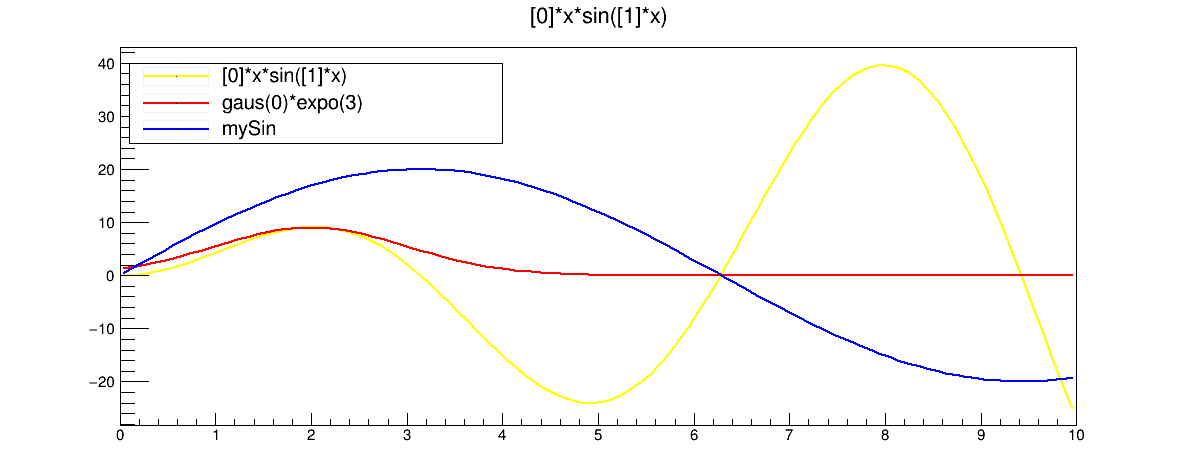

In [4]:
#!/usr/bin/python3
import math
import ROOT
from ROOT import TCanvas,TF1,TLegend


c=TCanvas('cFunctions','simple functions',1200,500)
f1=TF1("f1","[0]*x*sin([1]*x)",0.,10.)
f1.SetParameter(0,5.)
f1.SetParameter(1,1.)
f1.SetLineColor(ROOT.kYellow)
f1.DrawCopy()

f2=TF1('f2','gaus(x,[0..2])*expo(x,[3..4])',0.,10.)
f2.SetParameter(0,0.1)
f2.SetParameter(1,1.)
f2.SetParameter(2,1.)
f2.SetParameter(3,3.)
f2.SetParameter(4,1.)
f2.SetLineColor(ROOT.kRed)
f2.DrawCopy('same')

def mySin(x, par):
    return par[0]*math.sin(par[1]*x[0])

f3 = TF1('f3',mySin, 0., 10., 2)
f3.SetParameter(0, 20.);
f3.SetParameter(1, 0.5);
f3.SetLineColor(ROOT.kBlue)
f3.DrawCopy('same')

legend=TLegend(0.1,25,4.,40.,"","")
legend.AddEntry(f1,'[0]*x*sin([1]*x)')
legend.AddEntry(f2,'gaus(0)*expo(3)')
legend.AddEntry(f3,'mySin')
legend.Draw()

c.Update()
c.Draw()
c.Print('.png')

# Example 4 - uniform random number generator

Info in <TCanvas::Print>: png file ./cFlat.png has been created


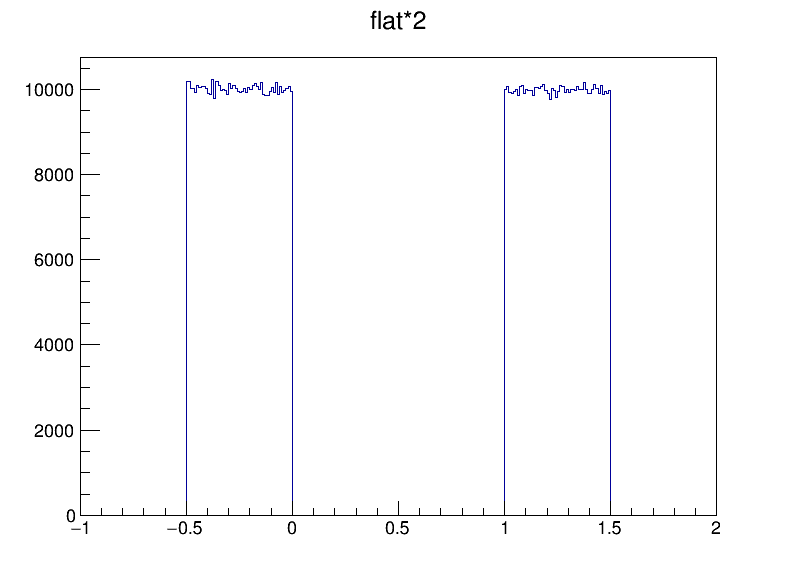

In [5]:
#!/usr/bin/python3
import math
from ROOT import gRandom,TH1D,TCanvas,TH1D,gStyle

gRandom.SetSeed(2018)
def myDistr() :
  val = gRandom.Uniform(1.)
  if val < 0.5 : val -= 0.5 
  else: val += 0.5 
  return val

sigma = math.sqrt(7./12)
mu = 0.5

cFlat = TCanvas('cFlat','cFlat',800,600)
hVal = TH1D('hVal','flat*2',300, -1., 2.)
hVal.SetStats(0)

for i in  range(1000000) :
  val=myDistr()
  hVal.Fill(val)

hVal.Draw()
cFlat.Update()
cFlat.Draw()
cFlat.Print('.png')


Warning in <TFile::Append>: Replacing existing TH1: hVal (Potential memory leak).
Info in <TCanvas::Print>: png file cCTG.png has been created


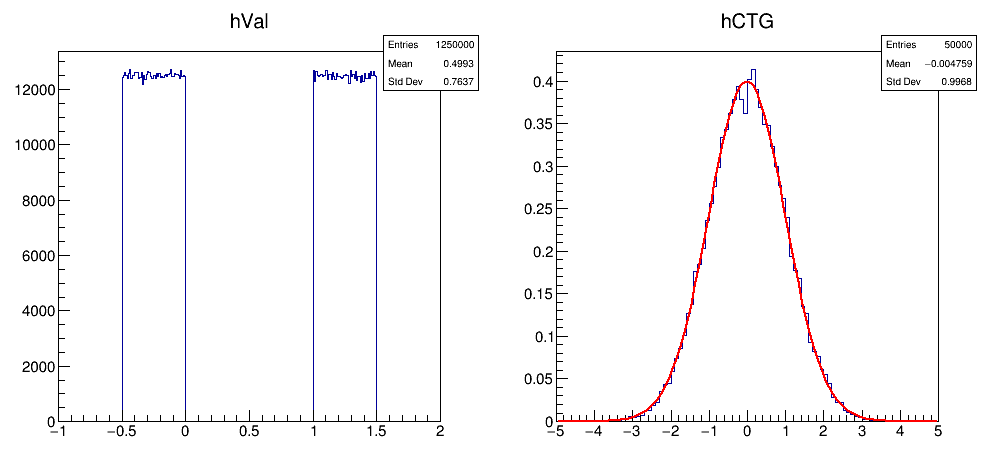

In [6]:
# 
#continuation
#

cCTG = TCanvas('cCTG','cCTG',1000,500)
hCTG = TH1D('hCTG','hCTG',100, -5., 5.)
hVal = TH1D('hVal','hVal',300, -1., 2.)

#
# loop over experiments, each gives and average X_i
#
nDistrib = 50000 #
for idist in range (0,nDistrib) :


# single try X_i, repeated nProb
#
  sum = 0
  nProb = 25 #enough for average
  for proba in range(0,nProb) :
    val = myDistr()
    hVal.Fill(val)
    sum += val
  #
  # result for singe X_i computation is histogrammed
  #
  ctg_numerator = (sum/nProb)-mu  
  ctg_denominator = sigma/math.sqrt(nProb)
  ctg = ctg_numerator/ctg_denominator
  hCTG.Fill(ctg)


gStyle.SetOptStat(1110)
cCTG.Divide(2,1)
cCTG.cd(1)
gStyle.SetOptStat(1110)
hVal.DrawCopy()

cCTG.cd(2)
hCTG.Scale(1./nDistrib*10)    #10 due to bin whdth
hCTG.Draw('hist')

g1 = TF1("g1", "gaus",-5,5 )
sigmaGauss = 1.
g1.SetParameter(0, 1./sigmaGauss/math.sqrt(2*math.pi) )
g1.SetParameter(1,0)
g1.SetParameter(2,sigmaGauss)
g1.DrawCopy('same')
cCTG.Draw()
cCTG.Print("cCTG.png")


# Example 5 - Fitting

point  i: 0  x= 1  y= 3.137077617374029  error= 0.31361437250351637
point  i: 1  x= 3  y= 5.4680412427707275  error= 0.5863478236728793
point  i: 2  x= 4  y= 4.211477419566066  error= 1.0623973613781965
point  i: 3  x= 5  y= 6.639568182544965  error= 0.27906094407876875
point  i: 4  x= 6  y= 9.378067491882083  error= 0.7825739772015229
point  i: 5  x= 7  y= 7.507250880449838  error= 0.9872741857507876
point  i: 6  x= 8  y= 10.388685557223763  error= 0.42130186693410965
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      11.5512
NDf                       =            5
Edm                       =  1.08783e-21
NCalls                    =           32
slope                     =     0.993487   +/-   0.0688108   
offset                    =      2.01194   +/-   0.336878    


Info in <TCanvas::Print>: png file cFitting.png has been created


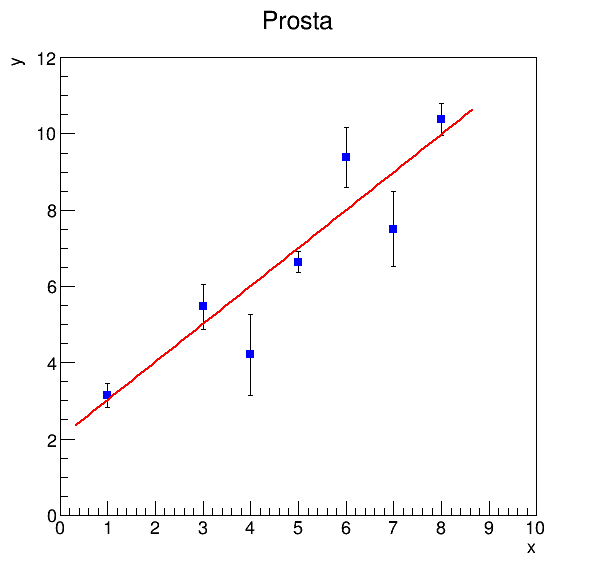

In [7]:
#!/usr/bin/python3

import sys
import math
import ROOT

def average_meas(points) :
  average = 0.
  for val in  points:
    average += val
  average /= len(points)
  return average

def sigma_meas(points) :
  average = average_meas(points)
  ss=0.
  for point in points: ss+= pow(point-average,2);
  sigma = math.sqrt(ss/(len(points)-1))
  return sigma


x = [ 1,  3,   4,   5,    6,   7,   8]
y = []
e = []
a=1.
b=2.
s = [ 1., 2., 3., 1., 2.,  3., 1.]
g = TF1("g","gaus",-20.,30.)
g.SetParameter(0,1.)
ROOT.gRandom.SetSeed(2025)

for i in range(len(x)):
  mean=a*x[i]+b
  g.SetParameter(1,mean)
  g.SetParameter(2,s[i])
  values = []
  nValues =10
  for j in range(nValues) :
    val = g.GetRandom()
    values.append(val)
  y.append(average_meas(values))
# e.append(s[i]/math.sqrt(nValues))
  e.append(sigma_meas(values)/math.sqrt(nValues))
  print ('point  i:',i,' x=',x[i],' y=',y[i],' error=',e[i])

gr=ROOT.TGraphErrors(7)
gr.SetMarkerColor(4)
gr.SetMarkerStyle(21)

for i in range (len(x)) :
  gr.SetPoint(i, x[i], y[i])
  gr.SetPointError(i, 0.,e[i])

c = ROOT.TCanvas('cFitting','cFitting',600,600)
hDummy = ROOT.TH1D('hDummy','Prosta',100,0.,10.)
hDummy.SetMaximum(12.)
hDummy.SetMinimum(0.)
hDummy.GetXaxis().SetTitle("x")
hDummy.GetYaxis().SetTitle("y")
hDummy.SetStats(0)
hDummy.DrawCopy()
 
gr.Draw('p')

fline = ROOT.TF1("flane", "[0]*x+[1]",0.,9.5)
fline.SetParName(0,"slope")
fline.SetParName(1,"offset")
gr.Fit(fline," ")
#gr.Fit('pol1'," ")

c.Print('cFitting.png')
c.Draw()

# Example 5 - Fitting manually with help of numpy

point  i: 0  x= 1.0  y= 2.3305497716275085  error= 0.34535608893314684
point  i: 1  x= 3.0  y= 5.795696359926258  error= 0.54803932026921
point  i: 2  x= 4.0  y= 7.545475724637645  error= 0.9677821648029868
point  i: 3  x= 5.0  y= 6.985439523588833  error= 0.30820130455615974
point  i: 4  x= 6.0  y= 7.815392962723381  error= 0.8897776692388386
point  i: 5  x= 7.0  y= 9.639110678040973  error= 0.6504965737010797
point  i: 6  x= 8.0  y= 9.781325701329177  error= 0.42209576471647786
Fitted values:  a = 1.0692630421540317,  b = 1.6493819900495534
fit    errors: sa = 0.07083068423281035, sb = 0.3596399175006832
chi2/NDF= 1.7353524377301084


Warning in <TCanvas::Constructor>: Deleting canvas with same name: cFitting
Warning in <TFile::Append>: Replacing existing TH1: hDummy (Potential memory leak).
Info in <TCanvas::Print>: png file cFitting.png has been created


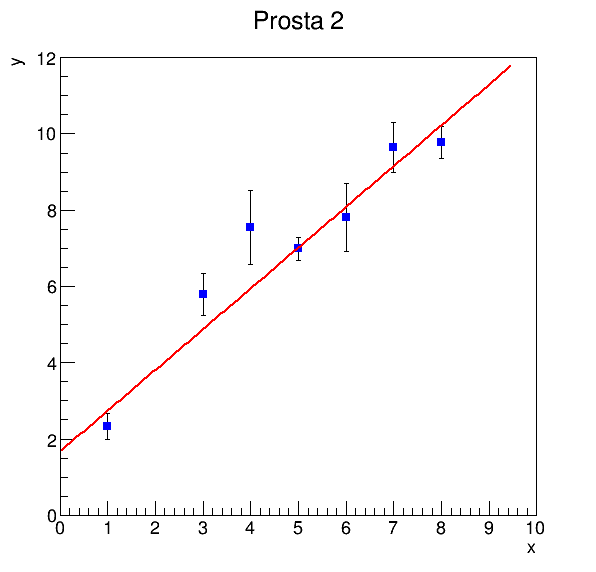

In [8]:
#!/usr/bin/python3

import sys
import math
import numpy as np
from array import array 
import ROOT

x = array('d',[ 1,  3,   4,   5,    6,   7,   8])
y = array('d',len(x)*[0.])
e = array('d',len(x)*[0.])
a = 1.
b = 2.
s = [ 1., 2., 3., 1., 2.,  3., 1.]
g = ROOT.TF1("g","gaus",-20.,30.)
g.SetParameter(0,1.)
ROOT.gRandom.SetSeed(2022)

for i in range(len(x)):
  mean=a*x[i]+b
  g.SetParameter(1,mean)
  g.SetParameter(2,s[i])
  values = []
  nValues =10
  for j in range(nValues) :
    val = g.GetRandom()
    values.append(val)

  y[i]=np.mean(values)
  e[i]=np.std(values,ddof=1)/math.sqrt(nValues) 
  print ('point  i:',i,' x=',x[i],' y=',y[i],' error=',e[i])

xnp = np.array(x)
ynp = np.array(y)
enp = np.array(e)

w=1.0/enp**2
S = np.sum(w)
Sx = np.sum(w*xnp)
Sy = np.sum(w*ynp)
Sxx = np.sum(w*xnp*xnp)
Sxy = np.sum(w*xnp*ynp)
  
D = S*Sxx-Sx*Sx
a_fit = (S*Sxy-Sx*Sy)/D
b_fit = (Sxx*Sy-Sx*Sxy)/D

d = (ynp-(a_fit*xnp+b_fit))/enp
chi2 = np.sum(np.square(d))
print("Fitted values:  a = {},  b = {}".format(a_fit,b_fit))
print("fit    errors: sa = {}, sb = {}".format(math.sqrt(S/D),math.sqrt(Sxx/D)))
print ('chi2/NDF=',chi2/(len(x)-2.))

gr = ROOT.TGraphErrors(len(x), x, y, array('d',len(x)*[0.]), e)
gr.SetMarkerColor(4)
gr.SetMarkerStyle(21)


c = ROOT.TCanvas('cFitting','cFitting',600,600)
hDummy = ROOT.TH1D('hDummy','Prosta 2',100,0.,10.)
hDummy.SetMaximum(12.)
hDummy.SetMinimum(0.)
hDummy.GetXaxis().SetTitle("x")
hDummy.GetYaxis().SetTitle("y")
hDummy.SetStats(0)
hDummy.DrawCopy()
 
gr.Draw('s p')

fline = ROOT.TF1("fline", "[0]*x+[1]",0.,9.5)
fline.SetParameter(0,a_fit)
fline.SetParameter(1,b_fit)
fline.Draw('same')

c.Print('cFitting.png')
hDummy.Delete()

c.Draw()

# Example 6 - event processing

In [9]:
#! /usr/bin/env python3
# -*- coding: utf-8 -*-

import sys
from ROOT import gROOT, gRandom, TFile, TTree 
from array import array

## A C/C++ structure is required, to allow memory based access
gROOT.ProcessLine(
   "struct Vertex_t {\
    Int_t id;\
    Double_t x,y,z; \
    double perp() { return sqrt(x*x+y*y); } \
};")

gRandom.SetSeed(2022)
vertex = ROOT.Vertex_t()
pid = array('i',[0])

f = TFile('myTree.root','RECREATE')
myTree  = TTree('myTree','simple tree with vertex data')
myTree.Branch('vertex',vertex)
myTree.Branch('pid',pid,'pid/I')

for i in range(1000) :
  pid[0] = gRandom.Integer(100)
  vertex.id = i
  vertex.x = gRandom.Uniform(10.)
  vertex.y = gRandom.Uniform(10.)
  vertex.z = gRandom.Gaus(10.,2.)
  
#  print ('vertex id:{0:3d}, perp={1:5.2f}'.format(vertex.id,vertex.perp()))
  myTree.Fill()       
myTree.Print("all")
f.Write()
f.Close()  


******************************************************************************
*Tree    :myTree    : simple tree with vertex data                           *
*Entries :     1000 : Total =           36231 bytes  File  Size =          0 *
*        :          : Tree compression factor =   1.00                       *
******************************************************************************
*Branch  :vertex                                                             *
*Entries :     1000 : BranchElement (see below)                              *
*............................................................................*
*Br    0 :id        : Int_t                                                  *
*Entries :     1000 : Total  Size=       4635 bytes  One basket in memory    *
*Baskets :        0 : Basket Size=      32000 bytes  Compression=   1.00     *
*............................................................................*
*Br    1 :x         : Double_t                      

# Example 7 - event analysis

entires: 1000
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      48.0514
NDf                       =           53
Edm                       =  9.70868e-07
NCalls                    =           61
Constant                  =      37.1702   +/-   1.53547     
Mean                      =      9.92732   +/-   0.0686582   
Sigma                     =      2.05768   +/-   0.0557854    	 (limited)


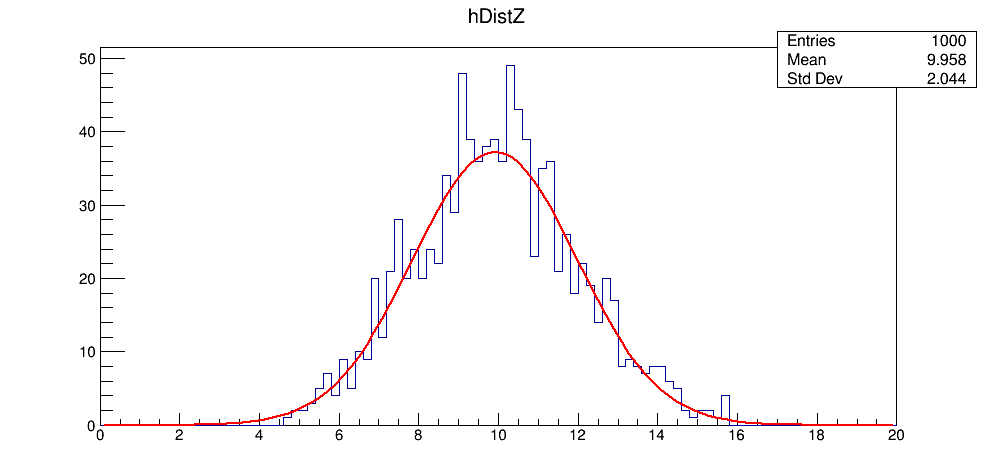

In [10]:
#! /usr/bin/env python3
# -*- coding: utf-8 -*-

import ROOT
from array import array
ROOT.gROOT.ProcessLine(
 "struct Vertex_t {\
    Int_t id;\
    Double_t x,y,z; \
    double perp() { return sqrt(x*x+y*y); } \
};")
pid=array('i',[0])
myVert=ROOT.Vertex_t()

myChain=ROOT.TChain('myTree')
myChain.Add('myTree.root')
myChain.SetBranchAddress("vertex",myVert)
myChain.SetBranchAddress("pid",pid)

cFitG = ROOT.TCanvas('cFitG','cFitG',1000,500)
hDistZ = ROOT.TH1D('hDistZ','hDistZ',100, 0., 20.)

nEntries = myChain.GetEntries()
for iev in range (nEntries) :
  myChain.GetEntry(iev)
  hDistZ.Fill(myVert.z)
#  print ('pid:{0:2d}, vertex id:{1:3d}, perp={2:5.2f}'.format(pid[0],myVert.id,myVert.perp()))
print ('entires:',nEntries)


hDistZ.DrawCopy()
g1 = ROOT.TF1("g1", "gaus",-5,5 )
sigmaGauss = 1.
g1.SetParameter(0, 1./sigmaGauss/math.sqrt(2*math.pi) )
g1.SetParameter(1,5.)
g1.SetParameter(2,sigmaGauss)

#
# fit histogram here
#
hDistZ.Fit(g1)
hDistZ.DrawCopy('same')

cFitG.Draw()

# Example 8 - not only pyROOT 

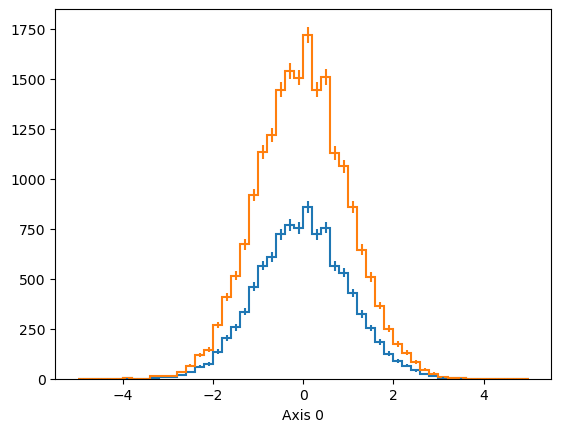

In [11]:
import numpy as np

import hist
from hist import Hist

histo = Hist(hist.axis.Regular(50, -5, 5))

data = np.random.randn(10000)

histo.fill(data)
histo.plot(); 

for aItem in data:
    histo.fill(aItem)
    
histo.plot();    

# Breit-Wigner Function Exercise

Understand how to use (non-relativistic) Breit-Wigner (BW) function (use ROOT library! check ROOT documentation) with $m=90$ and $\Gamma=2$. Generate $10^6$ events from B-W probability density distribution and fill a histogram.

- Plot B-W distribution function in reasonable range and plot properly scaled histogram with reasonable binning on the same picture.
- Fit B-W function to generated points. Plot fitted function with different color on the same plot.
- Do not forget to add legend and mark axes.

Generated 1000000 events. Histogram has 1000000.0 entries.
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      1108.12
NDf                       =          997
Edm                       =  6.45798e-08
NCalls                    =          105
p0                        =        39951   +/-   40.6705     
p1                        =           90   +/-   0.00141376  
p2                        =      1.99637   +/-   0.00291974  


Warning in <TROOT::Append>: Replacing existing TH1: hBW (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: cBW


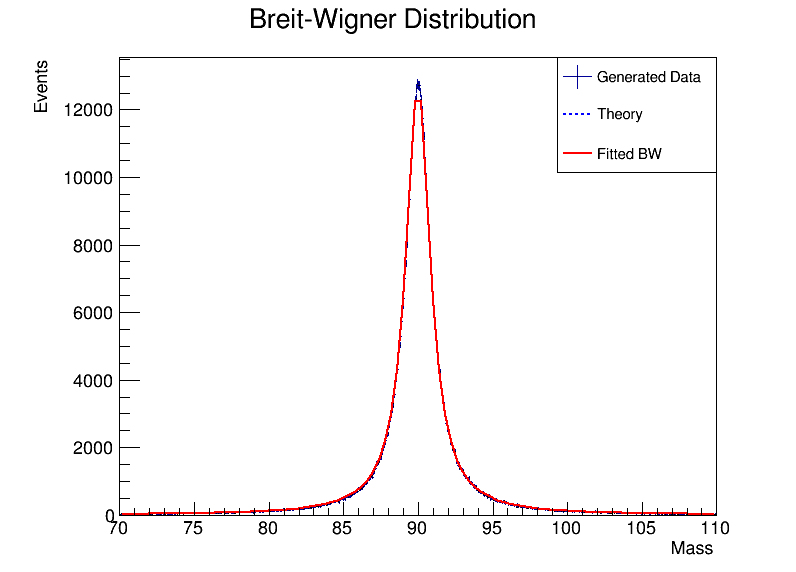

In [64]:
from ROOT import TH1D, gRandom

m = 90
gamma = 2
nEvents = int(1e6)

gRandom.SetSeed(12345)
hBW = TH1D('hBW', 'Breit-Wigner Distribution; Mass; Events', 1000, 70., 110.)
# hDistZ = ROOT.TH1D('hDistZ','hDistZ',100, 0., 20.)
hBW.Sumw2()

#events
for i in range(nEvents):
    x = gRandom.BreitWigner(m, gamma)
    hBW.Fill(x)

print(f"Generated {nEvents} events. Histogram has {hBW.GetEntries()} entries.")
hBW.SetStats(0)
hBW.DrawCopy() 


# g1 = ROOT.TF1("g1", "gaus",70,110 )
# sigmaGauss = 1.
# g1.SetParameter(0, 1./sigmaGauss/math.sqrt(2*math.pi) )
# g1.SetParameter(1,5.)
# g1.SetParameter(2,sigmaGauss)
# hBW.Fit(g1)

#fit
g2 = ROOT.TF1("g2", "breitwigner",70,110 )
g2.SetParameter(0, 0.)
g2.SetParameter(1, 90.)
g2.SetParameter(2, 2.)
hBW.Fit(g2)

#theory
theory_func = ROOT.TF1("theory", "breitwigner", 70, 110)
theory_func.SetParameters(1000, m, gamma)
theory_func.SetLineColor(ROOT.kBlue)
theory_func.SetLineStyle(2)
theory_func.Draw("same")


hBW.DrawCopy('same')
c = TCanvas('cBW', 'Breit-Wigner Histogram', 800, 600)
hBW.Draw()

#legend
legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)
legend.AddEntry(hBW, "Generated Data", "lep")
legend.AddEntry(theory_func, "Theory", "l")
legend.AddEntry(g2, "Fitted BW", "l")
legend.Draw()

c.SetLeftMargin(0.15)  #Space for printing Y label



c.Draw()

# cFitG.Draw()